In [21]:
import numpy as np
import matplotlib.pyplot as plt
import plothelpers
import utility as ut
import mesa_reader as mr

G    = 6.6743e-8    
c    = 2.99792458e10    # [cm]
Msun = 1.9891e33        # [g]
Rsun = 6.957e10         # [cm]
pc   = 3.08567758128e18 # [cm]
kpc  = 1.e3*pc          # [cm]
Mpc  = 1.e6*pc          # [cm] 
au   = 1.49598073e13    # [cm]
yr   = 31556952.        # [secs]

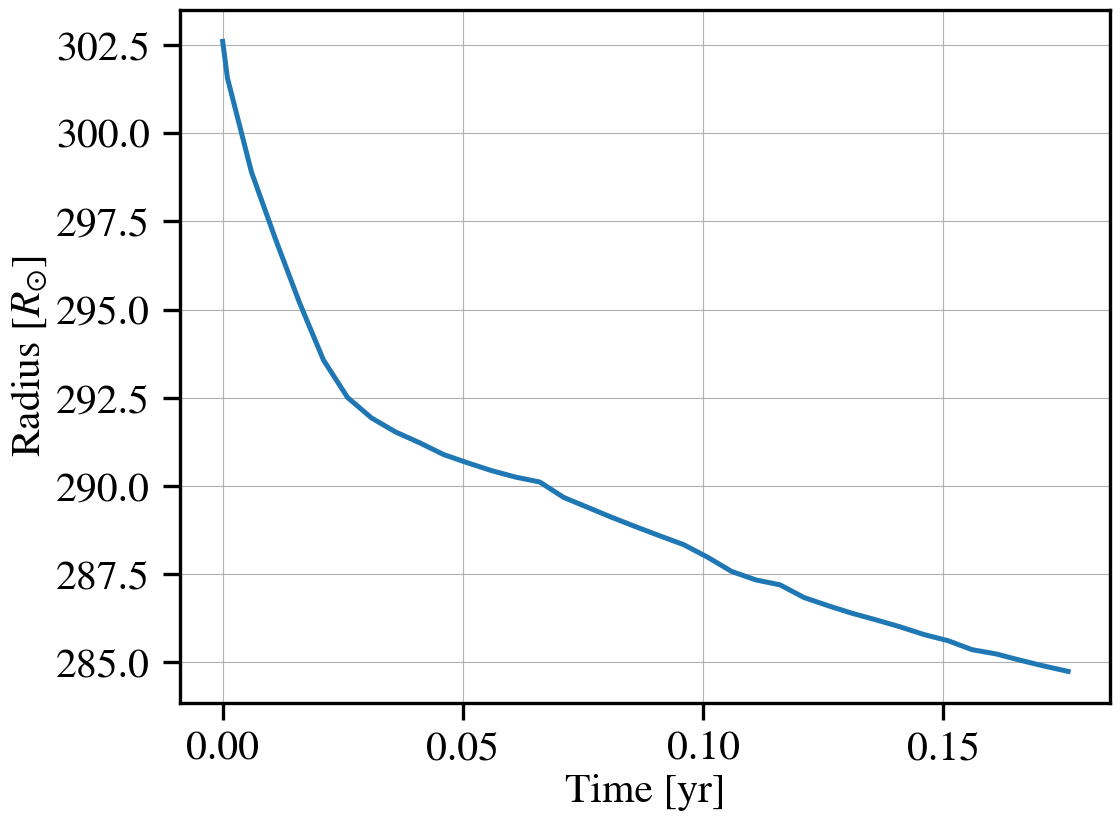

In [22]:
run1 = ut.readInspiralData('./NSAccretor1/', './RSGDonor1/')
#run2 = ut.readInspiralData('./NSData2/', './StarProfiles2/')
#run3 = ut.readInspiralData('./NSData3/', './StarProfiles3/')
#run4 = ut.readInspiralData('./NSData4/', './StarProfiles4/')
#run5 = ut.readInspiralData('./NSData5/', './StarProfiles5/')

fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel='Time [yr]', ylabel = 'Radius [$R_{\odot}$]', 
      )
ax.plot(run1.tl, run1.a)
#ax.plot(run2.tl, np.log10(run2.a), '-')
#ax.plot(run3.tl, np.log10(run3.a), '--')
#ax.plot(run4.tl, np.log10(run4.a), '--')
#ax.plot(run5.tl, np.log10(run5.a), '--')
ax.grid(True)

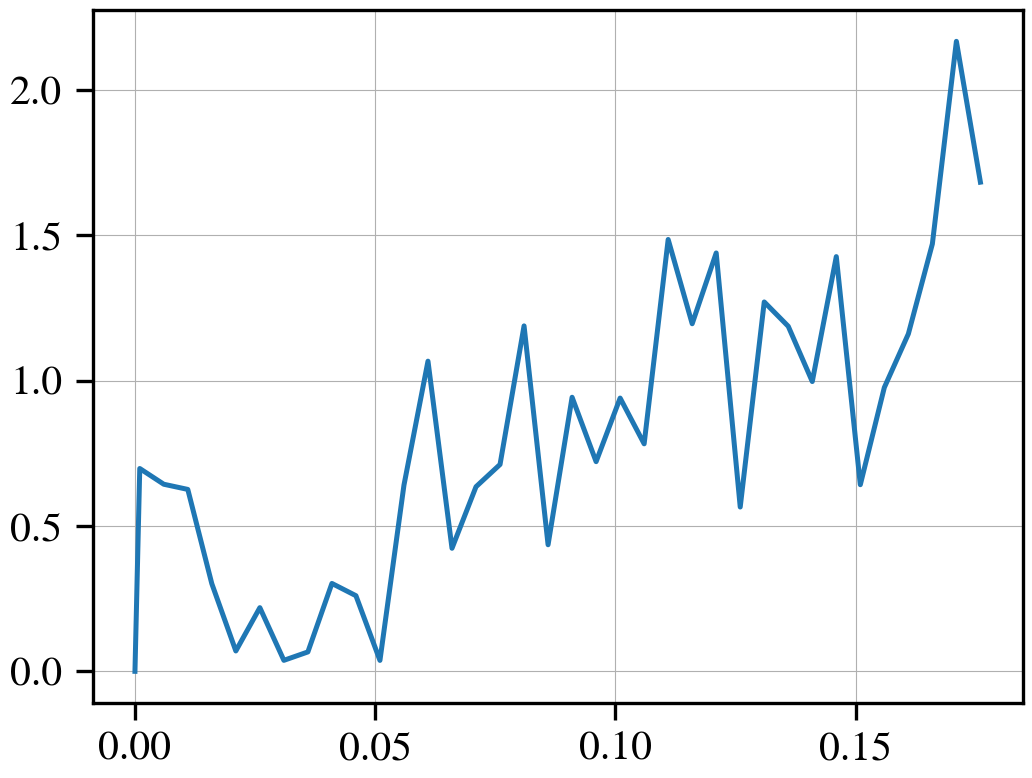

In [23]:
fig, ax = plt.subplots(facecolor='w')
ax.plot(run1.tl, run1.egrad)
ax.grid(True)

NameError: name 'run3' is not defined

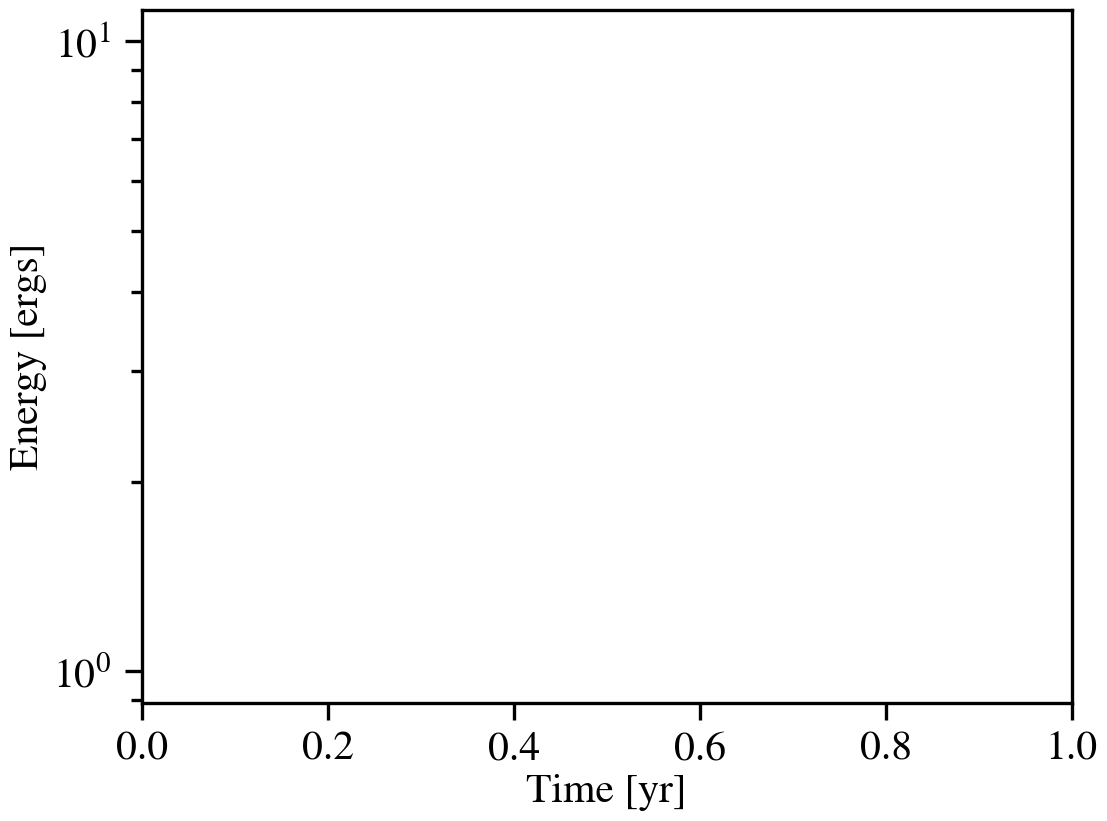

In [24]:
#run3 = ut.readInspiralData('./NSData3/', './StarProfiles3/')
fig,ax= plt.subplots(facecolor='w')
ax.set(yscale = 'log', xlabel = 'Time [yr]', ylabel = 'Energy [ergs]')

ax.plot(run3.tl, np.abs(run3.Eorb), color = 'blue', label = 'Orbital Energy')
ax.plot(run3.tl, np.abs(run3.Edrag), color = 'orange', label = 'Drag Energy')
ax.plot(run3.tl, np.abs(run3.Ebind), color ='red', label ='Binding Energy')
ax.plot(run3.tl, run3.Ejet, color = 'brown', label = 'Jet Energy')

ax.grid(True)
ax.legend(loc='best')

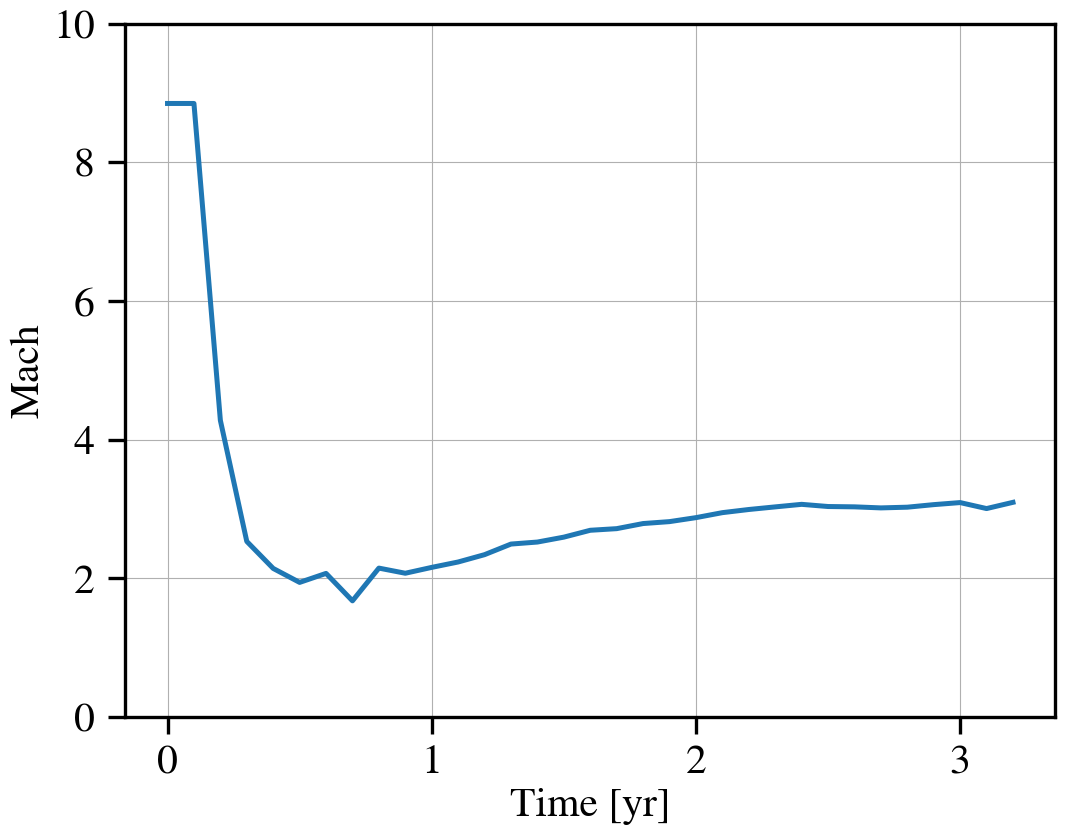

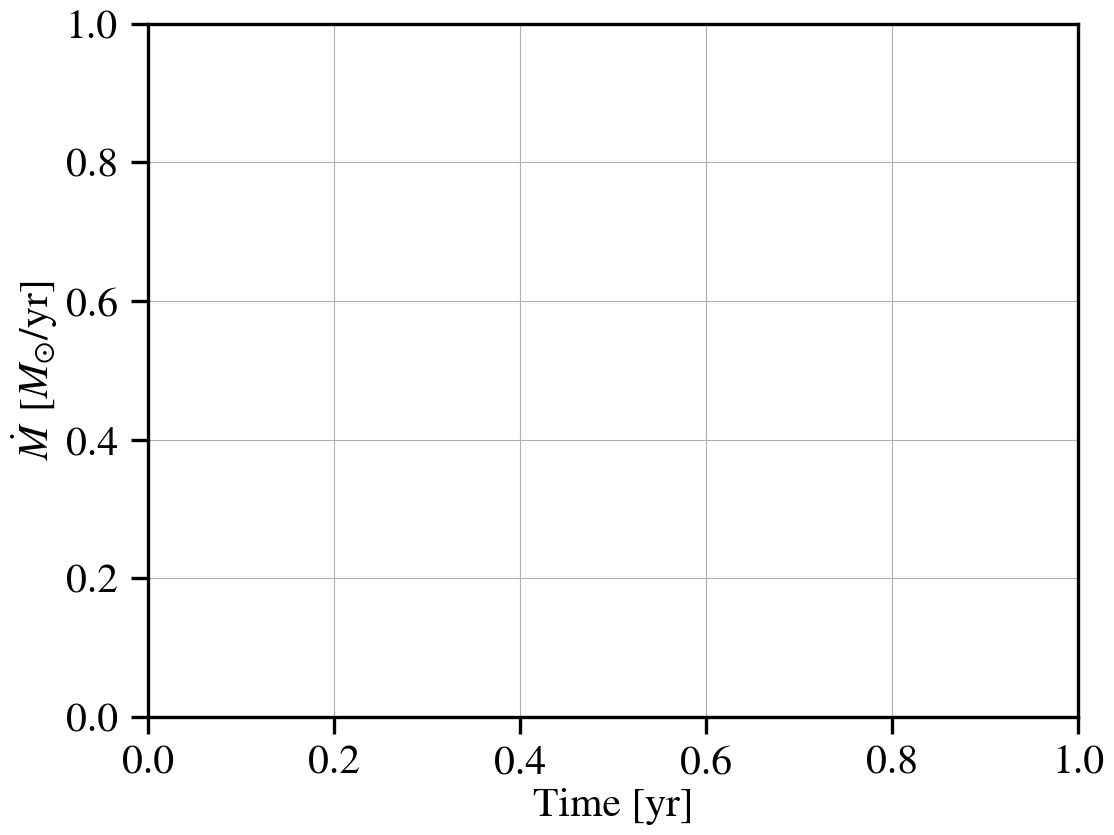

In [21]:
fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel='Time [yr]', ylabel = 'Mach', ylim = (0,10))

ax.plot(run1.tl, run1.Mach)
#ax.plot(run2.tl, run2.Mach)
#ax.plot(run3.tl, run3.Mach)
ax.grid(True)

fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel='Time [yr]', ylabel = '$\dot M$ [$M_{\odot}$/yr]', yscale = 'linear')
#ax.plot(run3.tl, run3.dmbs/Msun * yr)
ax.grid(True)

In [35]:
class getEnvelopeData:
    def __init__(self, starObject, filename, profileNum=1):
        
        massEscape, massUnbound, outerRadi, tList = [],[],[],[]
        IE_H, IE_He, LumLst, NucLst, ELst = [],[],[],[], []
        
        print('Iterations Needed: ', len(starObject.tl))
        for n in range(0, len(starObject.tl)):
            if(n % profileNum ==0):
                file      = starObject.pathDonor + '{}_'.format(n) + filename
                star1     = mr.MesaData(file)
                Rs, Rho   = 10**star1.data('logR')[::-1]*Rsun, 10**star1.data('logRho')[::-1]
                Mgrav     = star1.data('m_grav')[::-1]*Msun
                vel       = star1.data('velocity')[::-1]
                totalE    = star1.data('total_energy')[::-1]
                dq        = 10**star1.data('logdq')[::-1]
                totalNucE = star1.data('net_nuclear_energy')[::-1]
                
                #h0, x0    = df['neutral_fraction_H'].to_numpy()[::-1], df['x_mass_fraction_H'].to_numpy()[::-1]
                #he0, xhe0 = df['neutral_fraction_He'].to_numpy()[::-1], df['y_mass_fraction_He'].to_numpy()[::-1]
                #Lum, NucE = df['luminosity'].to_numpy()[::-1], df['net_nuclear_energy'].to_numpy()[::-1]

                escv     = np.sqrt((2*G*Mgrav)/Rs)
                indsVel  = np.argwhere((vel/escv) > 1)
                indsE    = np.argwhere(totalE > 0)
                massEscape.append(np.sum(dq[indsVel]*star1.star_mass*Msun)); massUnbound.append(np.sum( dq[indsE]*star1.star_mass*Msun))
                tList.append(starObject.tl[n]); outerRadi.append(Rs[-1]); ELst.append(np.trapz(totalE)); NucLst.append(np.trapz(totalNucE))

                # Calculate the ionizaiton energy of Hydrogen and Helium....
                #HEnergy  = np.sum((h0*13.6*x0)[0:-1] * np.diff((4/3)*np.pi*Rs*Rs*Rs))
                #HeEnergy = np.sum((he0*13.6*xhe0)[0:-1] * np.diff((4/3)*np.pi*Rs*Rs*Rs))
                #IE_H.append(HEnergy)
                #IE_He.append(HeEnergy)
            
                # Calculate the rate of change of luminsoity and Nuclear energy
                #LumLst.append(sum(np.diff(Lum)))
        
        print('Out of For Loop')
        self.time        = np.array(tList)
        self.outerRadius = np.array(outerRadi)
        self.massEscape  = np.array(massEscape)
        self.massUnbound = np.array(massUnbound)
        #self.IEHydrogen = IE_H
        #self.IEHelium = IE_He
        #self.LumRate = LumLst
        self.NucRate    = np.array(NucLst)
        self.TotalE     = np.array(ELst)
        self.starObject = starObject
        return

    def getEnergyKernel(self):
        kernelEnergy, kernelRadi = [], []
        for a in range(0, len(self.starObject.tl)):
            zones, energy, radi = np.loadtxt(self.starObject.pathAccretor + 'dragdonorZones_' + str(a), unpack = True, skiprows=0)
            print(zones)
            if (type(zones) == int):
                zones,energy,radi = np.array(zones), np.array(energy), np.array(radi)
            else:
                zones, energy, radi = zones[::-1], energy[::-1], radi[::-1]
            
            kernelEnergy.append(energy); kernelRadi.append(radi)

        self.kernelEnergy = kernelEnergy
        self.kernelRadi = kernelRadi
        return

In [36]:
class createKippenHahn:
    def __init__(self, eLst, rLst, time):
        self.energyLst = eLst
        self.radiLst   = rLst
        self.tl        = time
        self.iter      = len(time)
        
    def setGrid(self, rgridL, rgridR, sgrid = 2000):
        self.ns   = np.arange(0 ,self.iter, step=1)
        self.Rz   = np.logspace(np.log10(rgridL*Rsun),
                                np.log10(rgridR*Rsun),
                                sgrid)
        self.varg = np.zeros((sgrid, len(self.ns)))
        self.tgtest , self.rgtest = np.meshgrid(self.tl, self.Rz)
        print('Grid Set Up')
    def interpolate(self):
        for n in range(0, self.iter):
            Rs     = self.radiLst[n]
            energy = self.energyLst[n]
            vari = np.interp(self.Rz, Rs, energy)
            inds = np.argwhere(self.Rz > Rs[-1])
            inds2 = np.argwhere(self.Rz < Rs[0])
            vari[inds] = 0.
            vari[inds2] = 0.
            self.varg[:,n] = vari
        return self.varg

In [37]:
run1 = ut.readInspiralData('./NSData3/', './StarProfiles3/')
gravityE = G*run1.m1*run1.m2*Msun/run1.a*Rsun

In [38]:
obj10 = getEnvelopeData(run1, '12.0MsunProfile.data', 10)

Iterations Needed:  22
Out of For Loop


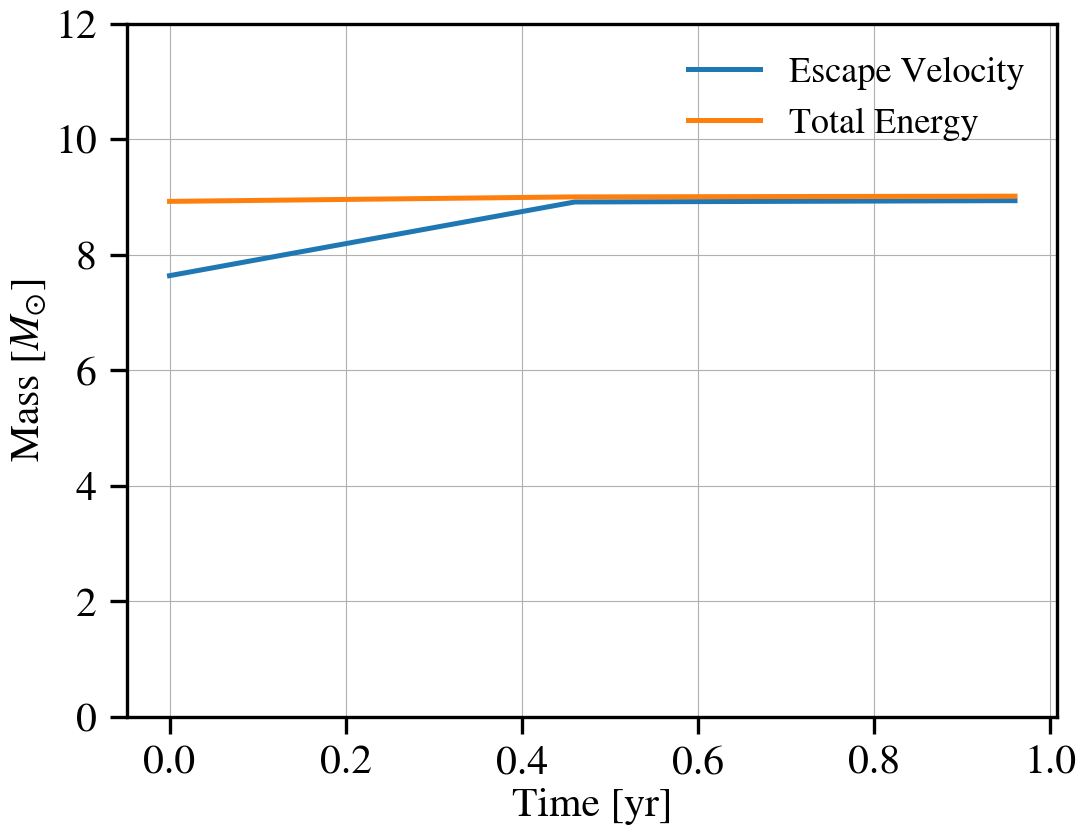

In [39]:
fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel = 'Time [yr]', ylabel = 'Mass [$M_{\odot}$]',
      ylim = (0,12.0))
ax.plot(obj10.time, obj10.massEscape/Msun, label = 'Escape Velocity')
ax.plot(obj10.time, obj10.massUnbound/Msun, label = 'Total Energy')
ax.grid(True)
ax.legend(loc='best')

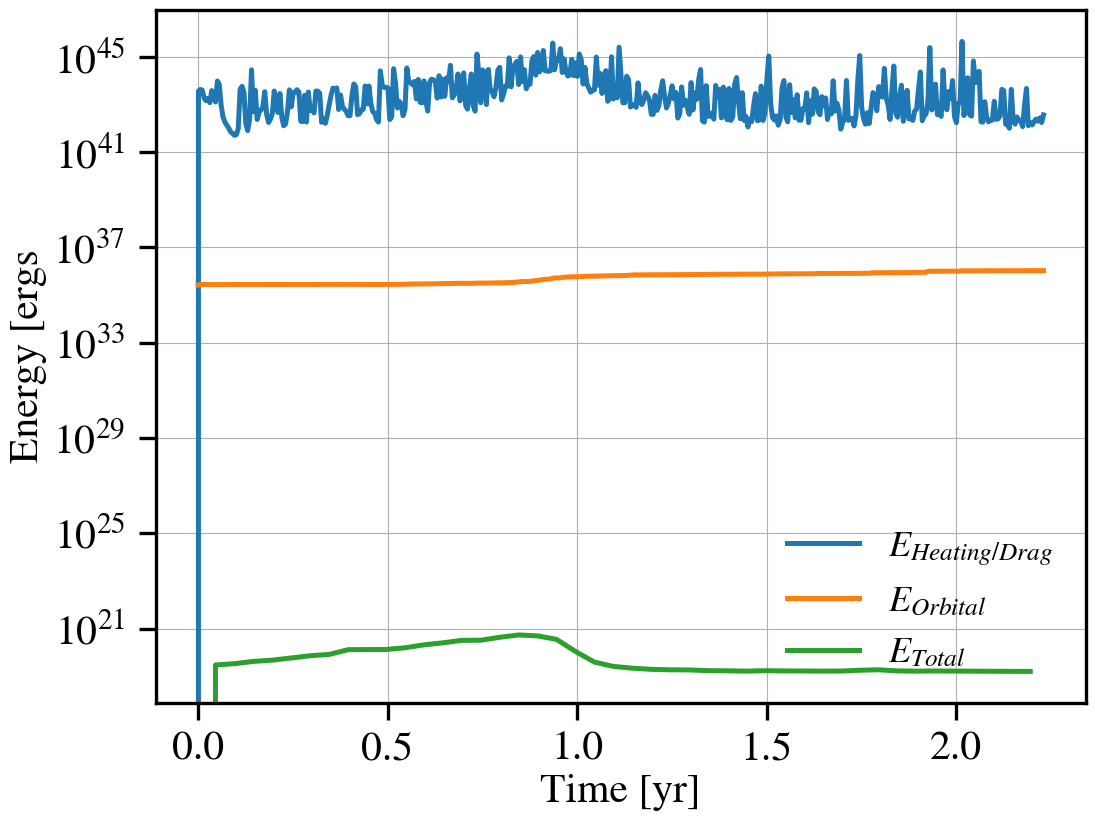

In [41]:
fig, ax = plt.subplots(facecolor='w')
ax.set(xlabel = 'Time [yr]', ylabel = 'Energy [ergs', yscale = 'log')
ax.plot(run1.tl, run1.Edrag, label = '$E_{Heating/Drag}$')
ax.plot(run1.tl, gravityE, label = '$E_{Orbital}$' )
ax.plot(obj10.time, obj10.TotalE, label = '$E_{Total}$')
#ax.plot(obj10.time, obj10.NucRate,'o', label = '$E_{Nuclear}$')

ax.grid(True)
ax.legend(loc='best')

In [53]:
kernelE, kernelR = obj10.kernelEnergy, obj10.kernelRadi
ob1 = createKippenHahn(kernelE, kernelR, run1.tl)
ob1.setGrid(1.e-1, int(1e5), 2000)
eKernel = ob1.interpolate()

Grid Set Up


[4.21677520e+13 1.26920444e+14 2.19715844e+14 3.12554523e+14
 4.05399615e+14 4.98245842e+14 5.91090866e+14 6.83936528e+14
 7.76784100e+14 8.69636014e+14 9.62490693e+14 1.05534765e+15
 1.14820757e+15 1.24106904e+15 1.33393415e+15 1.42680357e+15
 1.51967704e+15 1.61255457e+15 1.70543482e+15 1.79831926e+15
 1.89120617e+15 1.98409050e+15 2.07697397e+15 2.16985521e+15
 2.26273677e+15 2.35561761e+15 2.44848247e+15 2.54135849e+15
 2.63423742e+15 2.72711561e+15 2.81996485e+15 2.91284203e+15
 3.00571877e+15 3.09859502e+15 3.19147090e+15 3.28434639e+15
 3.37722136e+15 3.47009615e+15 3.56297056e+15 3.65584471e+15
 3.74871854e+15 3.84159207e+15 3.93446538e+15 4.02733839e+15
 4.12021111e+15]


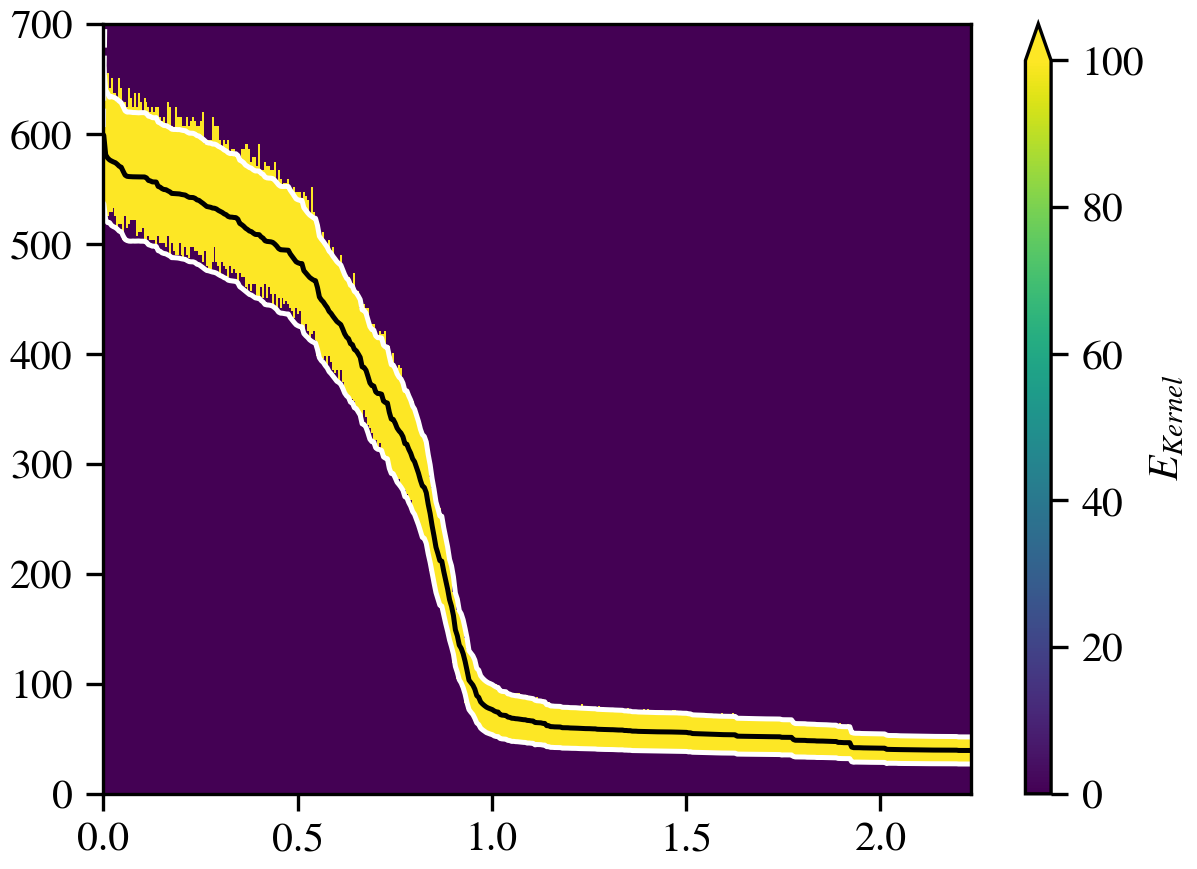

In [72]:
fig,ax = plt.subplots(figsize = (14, 10), facecolor = 'w')
ax.set(yscale = 'linear', ylim = (0, 700))

#ax.plot(run1.tl, np.log10(run1.a), color = 'black')
#ax.plot(run1.tl, np.log10(run1.RaccUpper), color = 'white')
#ax.plot(run1.tl, np.log10(run1.RaccLower), color = 'white')

ax.plot(run1.tl, run1.a, color = 'black')
ax.plot(run1.tl, run1.RaccUpper, color = 'white')
ax.plot(run1.tl, run1.RaccLower, color = 'white')
ax.plot(obj10.time, obj10.outerRadius/Rsun, color = 'white', linestyle ='--')

#im = ax.pcolormesh(ob1.tgtest, np.log10(ob1.rgtest/Rsun), np.log10(eKernel), cmap = 'turbo', vmin = 20,vmax = 40)
im = ax.pcolormesh(ob1.tgtest, ob1.rgtest/Rsun, eKernel, cmap = 'viridis',
                   vmin = 0,vmax = 100)
fig.colorbar(im, ax=ax, aspect = 30., pad = 0.05, extend = 'max',label = '$E_{Kernel}$')

In [110]:
def KippenhanPlot(self, kip_cedata, var, info):
    
    vlim,tlim, slim, labels_,labelT, color,sfig, sval, plotName = info
    
    if (sval == 'log10'): 
        print('log10')
        var = np.log10(var)
    elif(sval == 'log'): 
        var = np.log(var)
        
    fig,ax = plt.subplots(figsize = (14, 10), facecolor = 'w')
    ax.set(xlim   = (tlim[0],tlim[1]), 
           yscale = sfig,
           ylim   = (slim[0],slim[1]),
           xlabel = 'Time [yr]', 
           ylabel = r'$ R_{\odot}$', 
           title  = labelT)
    
    im = ax.pcolormesh(kip_cedata.tgtest, kip_cedata.rgtest/Rsun, var,
                       cmap = color, 
                       vmin = vlim[0],
                       vmax = vlim[1])
    
    ax.plot(self.inspiralData.tl, self.inspiralData.a,'--', color = 'white')
    ax.plot(self.inspiralData.tl, self.inspiralData.RaccUpper, '-', color = 'black')
    ax.plot(self.inspiralData.tl, self.inspiralData.RaccLower, '-', color = 'black')
    fig.colorbar(im, ax=ax, aspect = 30., pad = 0.05, extend = 'max',label = labels_)
    #plt.savefig('./Plots/' + plotName)